# LSTM Đa Biến với Entity Embedding

**Target**: `Units Sold`  
**Approach**: Entity Embedding cho 4 static categorical features (`Store ID`, `Product ID`, `Category`, `Region`) + numerical features (bao gồm `Weather Condition`, `Seasonality` dạng số) → LSTM multi-step forecast  
**Horizons**: 7, 14, 28 ngày

In [1]:
# import os

# print(os.listdir("/kaggle/input/datasets/thaonngyn/retail-store-inventory-and-demand-forecasting/sales_data.csv"))

In [7]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
import os
import kagglehub


tf.random.set_seed(42)
np.random.seed(42)

DATA_DIR = kagglehub.dataset_download("atomicd/retail-store-inventory-and-demand-forecasting")
DATA_PATH = os.path.join(DATA_DIR, "sales_data.csv")

#DATA_PATH  = "/kaggle/input/datasets/thaonngyn/retail-store-inventory-and-demand-forecasting/sales_data.csv"
RESULT_DIR = "/kaggle/working/"
TARGET     = 'Units Sold'
TRAIN_END  = '2023-06-30'
VAL_END    = '2023-10-31'
HORIZONS   = [7, 14, 28]
LOOKBACK   = 30
LAG        = 7

## 1. Load & Feature Engineering

In [8]:
df_raw = pd.read_csv(DATA_PATH)
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw = df_raw.sort_values(['Store ID', 'Product ID', 'Date']).reset_index(drop=True)

# ── Static categorical → entity embedding ────────────────────────────────────
CAT_COLS = ['Store ID', 'Product ID', 'Category', 'Region']
cat_vocabs = {}
for col in CAT_COLS:
    uniq = sorted(df_raw[col].unique())
    cat_vocabs[col] = {v: i for i, v in enumerate(uniq)}
    df_raw[col + '_enc'] = df_raw[col].map(cat_vocabs[col])

# ── Time-varying categoricals → ordinal encode vào numerical sequence ────────
WEATHER_MAP = {'Sunny': 0, 'Cloudy': 1, 'Rainy': 2, 'Snowy': 3, 'Windy': 4, 'Stormy': 5}
SEASON_MAP  = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Fall': 3}
df_raw['weather_enc']  = df_raw['Weather Condition'].map(WEATHER_MAP).fillna(0).astype(int)
df_raw['season_enc']   = df_raw['Seasonality'].map(SEASON_MAP).fillna(0).astype(int)

# ── Numerical features ────────────────────────────────────────────────────────
grp = df_raw.groupby(['Store ID', 'Product ID'])[TARGET]
df_raw['lag_7']           = grp.shift(7)
df_raw['lag_14']          = grp.shift(14)
df_raw['lag_28']          = grp.shift(28)
df_raw['rolling_mean_7']  = grp.transform(lambda x: x.shift(1).rolling(7).mean())
df_raw['rolling_mean_14'] = grp.transform(lambda x: x.shift(1).rolling(14).mean())
df_raw['day_of_week']     = df_raw['Date'].dt.dayofweek
df_raw['day_of_month']    = df_raw['Date'].dt.day
df_raw['month']           = df_raw['Date'].dt.month
df_raw['is_weekend']      = (df_raw['day_of_week'] >= 5).astype(int)
df_raw = df_raw.bfill().fillna(0)

NUM_COLS = [
    TARGET,
    'Price', 'Discount', 'Competitor Pricing',
    'Inventory Level', 'Units Ordered',
    'Promotion', 'Epidemic',
    'weather_enc', 'season_enc',          # time-varying — giữ trong sequence
    'lag_7', 'lag_14', 'lag_28',
    'rolling_mean_7', 'rolling_mean_14',
    'day_of_week', 'day_of_month', 'month', 'is_weekend',
]
TARGET_IDX = NUM_COLS.index(TARGET)
ENC_COLS   = [c + '_enc' for c in CAT_COLS]

series_keys = sorted(df_raw.groupby(['Store ID', 'Product ID']).groups.keys())
print(f'Series: {len(series_keys)} | Num features: {len(NUM_COLS)} | Static cat: {len(CAT_COLS)}')
print('Vocab sizes:', {c: len(v) for c, v in cat_vocabs.items()})

Series: 100 | Num features: 19 | Static cat: 4
Vocab sizes: {'Store ID': 5, 'Product ID': 20, 'Category': 5, 'Region': 4}


## 2. Model với Entity Embedding

In [9]:
def embedding_dim(vocab_size):
    """Rule of thumb: min(50, (vocab_size + 1) // 2)"""
    return min(50, (vocab_size + 1) // 2)

def build_model(lookback, n_num, cat_vocab_sizes, horizon, lstm_units=64, dropout=0.2):
    """
    Inputs:
      - num_input : (batch, lookback, n_num)  — numerical sequence
      - cat_input_i: (batch,)                 — one per categorical (static per series)
    """
    num_input = layers.Input(shape=(lookback, n_num), name='num_input')

    # Entity embeddings (static — same value repeated across timesteps)
    cat_inputs, cat_embeds = [], []
    for i, (col, vocab_size) in enumerate(cat_vocab_sizes.items()):
        inp = layers.Input(shape=(1,), name=f'cat_{i}', dtype='int32')
        emb = layers.Embedding(vocab_size, embedding_dim(vocab_size), name='emb_' + col.replace(' ', '_'))(inp)
        emb = layers.Flatten()(emb)
        cat_inputs.append(inp)
        cat_embeds.append(emb)

    # Tile embeddings across timesteps and concat with numerical
    if cat_embeds:
        cat_concat = layers.Concatenate()(cat_embeds) if len(cat_embeds) > 1 else cat_embeds[0]
        emb_dim    = cat_concat.shape[-1]
        cat_tiled  = layers.RepeatVector(lookback)(cat_concat)  # (batch, lookback, emb_dim)
        x = layers.Concatenate(axis=-1)([num_input, cat_tiled])
    else:
        x = num_input

    x = layers.LSTM(lstm_units, return_sequences=True)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(lstm_units // 2)(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(horizon)(x)

    model = models.Model(inputs=[num_input] + cat_inputs, outputs=out)
    model.compile(optimizer='adam', loss='mse')
    return model

# Vocab sizes theo thứ tự CAT_COLS
cat_vocab_sizes = {col: len(cat_vocabs[col]) for col in CAT_COLS}

# Preview model
demo = build_model(LOOKBACK, len(NUM_COLS), cat_vocab_sizes, horizon=7)
demo.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ cat_0 (InputLayer)            │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cat_1 (InputLayer)            │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cat_2 (InputLayer)            │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cat_3 (InputLayer)            │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ emb_Store_ID (Embedding)      │ (None, 1, 3)              │              15 │ cat_0[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ emb_Product_ID (Embedding)    │ (None, 1, 10)             │             200 │ cat_1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ emb_Category (Embedding)      │ (None, 1, 3)              │              15 │ cat_2[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ emb_Region (Embedding)        │ (None, 1, 2)              │               8 │ cat_3[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 3)                 │               0 │ emb_Store_ID[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_1 (Flatten)           │ (None, 10)                │               0 │ emb_Product_ID[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_2 (Flatten)           │ (None, 3)                 │               0 │ emb_Category[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_3 (Flatten)           │ (None, 2)                 │               0 │ emb_Region[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 18)                │               0 │ flatten[0][0],             │
│                               │                           │                 │ flatten_1[0][0],           │
│                               │                           │                 │ flatten_2[0][0],           │
│                               │                           │                 │ flatten_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ num_input (InputLayer)        │ (None, 30, 19)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ repeat_vector (RepeatVector)  │ (None, 30, 18)            │               0 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 30, 37)            │               

 Total params: 38,997 (152.33 KB)

 Trainable params: 38,997 (152.33 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Build Dataset

In [10]:
def make_sequences(num_arr, cat_row, target_idx, lookback, horizon, stride=7):
    """
    num_arr  : (T, n_num) scaled numerical
    cat_row  : (n_cat,)   encoded categorical values (static for this series)
    Returns  : X_num (N, lookback, n_num), X_cats list of (N,), y (N, horizon)
    """
    X_num, y = [], []
    for i in range(lookback, len(num_arr) - horizon + 1, stride):
        X_num.append(num_arr[i - lookback:i])
        y.append(num_arr[i:i + horizon, target_idx])
    X_num = np.array(X_num, dtype=np.float32)
    y     = np.array(y, dtype=np.float32)
    n     = len(X_num)
    X_cats = [np.full(n, cat_row[j], dtype=np.int32) for j in range(len(cat_row))]
    return X_num, X_cats, y


def build_global_arrays(horizon, lookback):
    X_num_tr, X_num_vl = [], []
    X_cats_tr = [[] for _ in CAT_COLS]
    X_cats_vl = [[] for _ in CAT_COLS]
    y_tr, y_vl = [], []
    scalers = {}

    for store, product in series_keys:
        sdf = df_raw[(df_raw['Store ID'] == store) & (df_raw['Product ID'] == product)]
        sdf = sdf.set_index('Date')
        key = f'{store}_{product}'

        num_data = sdf[NUM_COLS].values.astype(np.float32)
        cat_row  = sdf[ENC_COLS].iloc[0].values.astype(np.int32)

        train_num = sdf[:TRAIN_END][NUM_COLS].values.astype(np.float32)
        val_num   = sdf[:VAL_END][NUM_COLS].values.astype(np.float32)

        scaler = StandardScaler().fit(train_num)
        scalers[key] = scaler

        tr_scaled  = scaler.transform(train_num)
        val_scaled = scaler.transform(val_num)

        Xn_tr, Xc_tr, yt = make_sequences(tr_scaled,  cat_row, TARGET_IDX, lookback, horizon)
        Xn_vl, Xc_vl, yv = make_sequences(val_scaled, cat_row, TARGET_IDX, lookback, horizon)

        X_num_tr.append(Xn_tr); X_num_vl.append(Xn_vl)
        y_tr.append(yt);        y_vl.append(yv)
        for j in range(len(CAT_COLS)):
            X_cats_tr[j].append(Xc_tr[j])
            X_cats_vl[j].append(Xc_vl[j])

    X_num_tr = np.concatenate(X_num_tr)
    X_num_vl = np.concatenate(X_num_vl)
    y_tr     = np.concatenate(y_tr)
    y_vl     = np.concatenate(y_vl)
    X_cats_tr = [np.concatenate(x) for x in X_cats_tr]
    X_cats_vl = [np.concatenate(x) for x in X_cats_vl]

    return X_num_tr, X_cats_tr, y_tr, X_num_vl, X_cats_vl, y_vl, scalers


print('Dataset builder ready.')

Dataset builder ready.


## 4. Rolling Evaluation

In [11]:
def rolling_eval(model, scaler, store, product, horizon, lookback):
    sdf = df_raw[(df_raw['Store ID'] == store) & (df_raw['Product ID'] == product)].set_index('Date')
    cat_row = sdf[ENC_COLS].iloc[0].values.astype(np.int32)

    full_scaled = scaler.transform(sdf[NUM_COLS].values.astype(np.float32))
    eval_start  = pd.Timestamp(VAL_END) + pd.Timedelta(days=1)
    eval_end    = sdf.index.max()

    all_fc, all_ac = [], []
    t = eval_start
    while t + pd.Timedelta(days=horizon - 1) <= eval_end:
        t_loc     = sdf.index.get_loc(t)
        win_start = t_loc - lookback
        if win_start < 0:
            t += pd.Timedelta(days=horizon); continue
        actual = sdf[TARGET][t: t + pd.Timedelta(days=horizon - 1)].values
        if len(actual) < horizon:
            t += pd.Timedelta(days=horizon); continue

        X_num  = full_scaled[win_start:t_loc][np.newaxis]  # (1, lookback, n_num)
        X_cats = [np.array([[cat_row[j]]], dtype=np.int32).reshape(1,1) for j in range(len(CAT_COLS))]
        # model cat inputs expect shape (batch,) not (batch,1) — squeeze
        X_cats = [c.flatten() for c in X_cats]
        X_cats_in = [c[np.newaxis] for c in X_cats]  # (1,)

        fc_scaled = model.predict([X_num] + X_cats_in, verbose=0)[0]  # (horizon,)
        dummy = np.zeros((horizon, len(NUM_COLS)), dtype=np.float32)
        dummy[:, TARGET_IDX] = fc_scaled
        fc = np.clip(scaler.inverse_transform(dummy)[:, TARGET_IDX], 0, None)

        all_fc.append(fc)
        all_ac.append(actual.astype(np.float32))
        t += pd.Timedelta(days=horizon)

    if not all_fc:
        return {k: np.nan for k in ['smape', 'mase', 'rmse', 'rmsle']}

    fc_arr, ac_arr = np.array(all_fc), np.array(all_ac)
    train_vals = sdf[TARGET][:TRAIN_END].values.astype(np.float32)
    lag   = min(LAG, len(train_vals) - 1)
    denom = np.mean(np.abs(train_vals[lag:] - train_vals[:-lag])) or 1.0

    return {
        'smape': (2 * np.abs(fc_arr - ac_arr) / (np.abs(fc_arr) + np.abs(ac_arr) + 1e-8)).mean() * 100,
        'mase' : np.mean(np.abs(fc_arr - ac_arr)) / denom,
        'rmse' : float(np.sqrt(np.mean((fc_arr - ac_arr) ** 2))),
        'rmsle': float(np.sqrt(np.mean((np.log1p(np.clip(fc_arr, 0, None)) - np.log1p(np.clip(ac_arr, 0, None))) ** 2))),
    }


print('Evaluation function ready.')

Evaluation function ready.


## 5. Train & Evaluate

In [12]:
import os
os.makedirs(RESULT_DIR, exist_ok=True)

results = []

for h in HORIZONS:
    print(f'\n=== Horizon = {h} ===')
    print('  Building arrays...')
    X_num_tr, X_cats_tr, y_tr, X_num_vl, X_cats_vl, y_vl, scalers = build_global_arrays(h, LOOKBACK)
    print(f'  Train: {X_num_tr.shape} | Val: {X_num_vl.shape}')

    model = build_model(LOOKBACK, len(NUM_COLS), cat_vocab_sizes, horizon=h)

    cb = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model.fit(
        [X_num_tr] + X_cats_tr, y_tr,
        validation_data=([X_num_vl] + X_cats_vl, y_vl),
        epochs=50, batch_size=256,
        callbacks=[cb], verbose=0
    )

    print('  Rolling eval on TEST...')
    scores = {k: [] for k in ['smape', 'mase', 'rmse', 'rmsle']}
    for i, (store, product) in enumerate(series_keys):
        key = f'{store}_{product}'
        r   = rolling_eval(model, scalers[key], store, product, h, LOOKBACK)
        for k in scores: scores[k].append(r[k])
        print(f"    {store} | {product} | sMAPE={r['smape']:.2f}% MASE={r['mase']:.4f} RMSE={r['rmse']:.2f} RMSLE={r['rmsle']:.4f}")

    row = {
        'model':         'LSTM-EntityEmbedding',
        'dataset':       'retail_inventory_daily',
        'target':        TARGET,
        'horizon':       h,
        'lookback':      LOOKBACK,
        'mean_smape':    round(float(np.nanmean(scores['smape'])), 4),
        'median_smape':  round(float(np.nanmedian(scores['smape'])), 4),
        'mean_mase':     round(float(np.nanmean(scores['mase'])), 4),
        'median_mase':   round(float(np.nanmedian(scores['mase'])), 4),
        'mean_rmse':     round(float(np.nanmean(scores['rmse'])), 4),
        'median_rmse':   round(float(np.nanmedian(scores['rmse'])), 4),
        'mean_rmsle':    round(float(np.nanmean(scores['rmsle'])), 4),
        'median_rmsle':  round(float(np.nanmedian(scores['rmsle'])), 4),
    }
    results.append(row)
    print(f"  H={h} | sMAPE={row['mean_smape']:.2f}% MASE={row['mean_mase']:.4f} RMSE={row['mean_rmse']:.2f} RMSLE={row['mean_rmsle']:.4f}")

out_path = f'{RESULT_DIR}/lstm_entity_emb_summary.csv'
pd.DataFrame(results).to_csv(out_path, index=False)
print(f'\nSaved to {out_path}')
pd.DataFrame(results)


=== Horizon = 7 ===
  Building arrays...
  Train: (7300, 30, 19) | Val: (9100, 30, 19)
  Rolling eval on TEST...
    S001 | P0001 | sMAPE=35.05% MASE=0.8556 RMSE=40.73 RMSLE=0.4935
    S001 | P0002 | sMAPE=32.52% MASE=0.7387 RMSE=37.89 RMSLE=0.4573
    S001 | P0003 | sMAPE=38.86% MASE=0.8120 RMSE=53.74 RMSLE=0.5733
    S001 | P0004 | sMAPE=40.43% MASE=0.8147 RMSE=38.02 RMSLE=0.7309
    S001 | P0005 | sMAPE=38.07% MASE=0.7628 RMSE=44.98 RMSLE=0.4820
    S001 | P0006 | sMAPE=47.26% MASE=0.7625 RMSE=45.12 RMSLE=0.9185
    S001 | P0007 | sMAPE=43.08% MASE=0.8400 RMSE=54.06 RMSLE=0.6438
    S001 | P0008 | sMAPE=33.32% MASE=0.7499 RMSE=32.83 RMSLE=0.4676
    S001 | P0009 | sMAPE=33.47% MASE=0.8972 RMSE=44.94 RMSLE=0.4256
    S001 | P0010 | sMAPE=37.98% MASE=0.8224 RMSE=32.41 RMSLE=0.4919
    S001 | P0011 | sMAPE=39.26% MASE=0.8015 RMSE=32.80 RMSLE=0.5302
    S001 | P0012 | sMAPE=36.37% MASE=0.7118 RMSE=43.99 RMSLE=0.5491
    S001 | P0013 | sMAPE=47.31% MASE=0.9541 RMSE=42.82 RMSLE=0.7106
  

,model,dataset,target,horizon,lookback,mean_smape,median_smape,mean_mase,median_mase,mean_rmse,median_rmse,mean_rmsle,median_rmsle
0,LSTM-EntityEmbedding,retail_inventory_daily,Units Sold,7,30,40.0100,40.4976,0.8256,0.8263,42.4749,42.6800,0.6318,0.6227
1,LSTM-EntityEmbedding,retail_inventory_daily,Units Sold,14,30,39.6652,39.4091,0.7984,0.7979,41.2147,41.5982,0.6247,0.5948
2,LSTM-EntityEmbedding,retail_inventory_daily,Units Sold,28,30,39.0384,39.5645,0.7891,0.7901,40.4663,40.8626,0.6275,0.5986


## 6. Visualise Learned Embeddings (Store & Product)

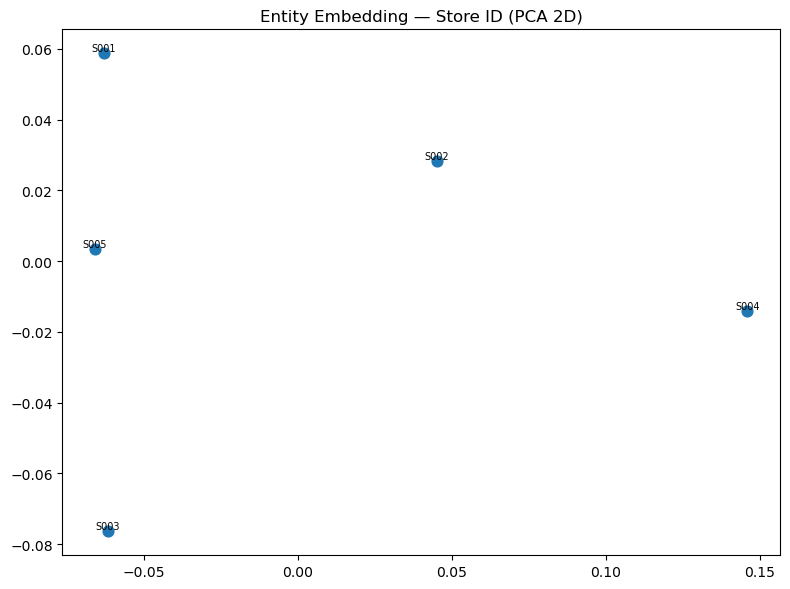

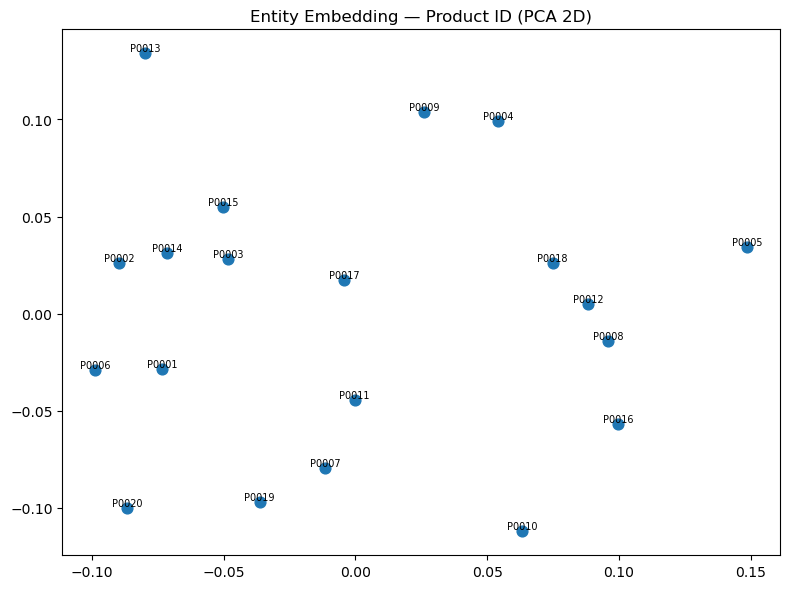

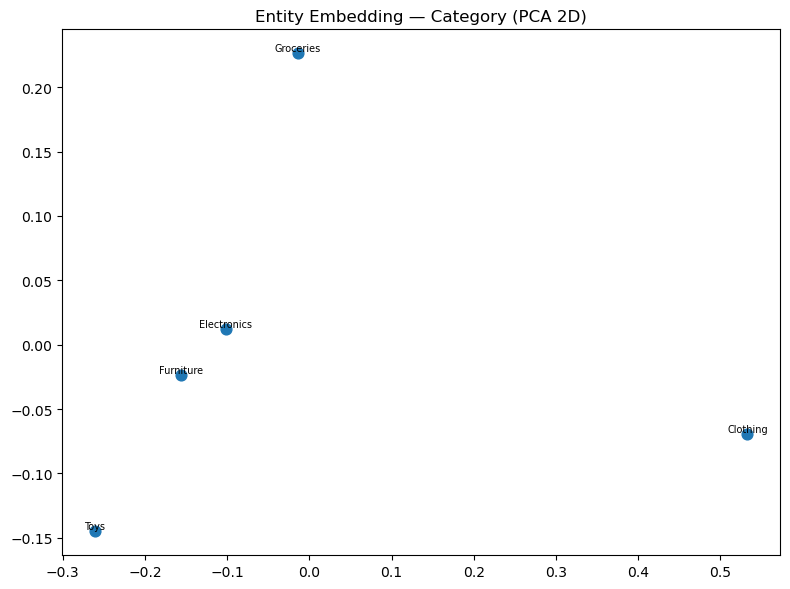

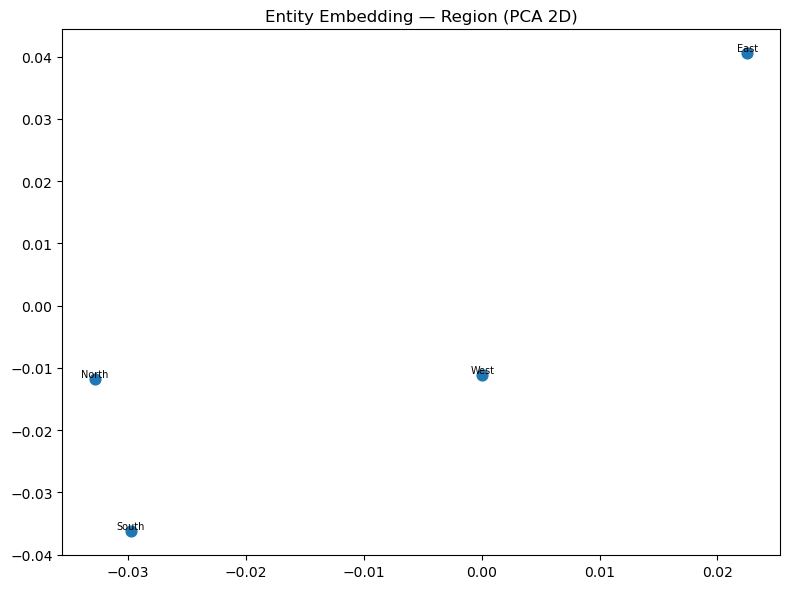

In [13]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Dùng model của horizon cuối cùng
for col_name in ['Store ID', 'Product ID', 'Category', 'Region']:
    emb_layer = model.get_layer('emb_' + col_name.replace(' ', '_'))
    weights   = emb_layer.get_weights()[0]  # (vocab_size, emb_dim)
    labels    = list(cat_vocabs[col_name].keys())

    if weights.shape[1] > 2:
        coords = PCA(n_components=2).fit_transform(weights)
    else:
        coords = weights

    plt.figure(figsize=(8, 6))
    plt.scatter(coords[:, 0], coords[:, 1], s=60)
    for i, lbl in enumerate(labels):
        plt.annotate(lbl, coords[i], fontsize=7, ha='center', va='bottom')
    plt.title(f'Entity Embedding — {col_name} (PCA 2D)')
    plt.tight_layout()
    plt.show()